# Part 5 - Putting them together

Four parts in, you have both halves:

| from | you understand |
|---|---|
| Part 1 | an fMRI volume is a 64 x 64 x 30 box of numbers, one every 2.16 s |
| Part 2 | the first 6 volumes are junk, and the real signal is about 1% of the number |
| Part 3 | EEG is 64 electrodes at 250 Hz, in microvolts |
| Part 4 | one 2.16 s EEG window becomes a 64 x 249 picture |

This part joins them. At the end you will have built a real training pair with your own hands,
saved it, read it back, and looked at it.

**Goal of this part:** understand exactly how 300 volumes become 274 training examples, and be
able to verify your processed dataset is correct before you spend hours training on it.

---

### The one-sentence version

Each training example is: **20 consecutive EEG pictures in, one fMRI volume out** - and the volume
is the one that comes immediately after those 20 windows.

---

### This notebook stands alone

Part 5 is a new file, so it does not need Parts 1-4 in memory. It rebuilds what it needs. It does
assume you have read them, though - it will not re-explain what a voxel or a spectrogram is.

**A warning about memory.** This part builds a full subject's training tensors, which is roughly
1 GB of RAM at peak. If your machine is tight on memory, close other programs first. Step 11 shows
you how to work with a smaller slice instead.

## Step 1 - Setup

In [1]:
%pip install -q mne nibabel numpy matplotlib h5py

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mne
import nibabel as nib
import h5py                      # for reading and writing .h5 files
from pathlib import Path
from scipy.fft import fft
from scipy.stats import zscore

mne.set_log_level("ERROR")

# Silence the ECG montage warning we already understand from Part 3.
import warnings
warnings.filterwarnings("ignore", message=".*coordinate information.*")
warnings.filterwarnings("ignore", message=".*misc channel.*")

plt.rcParams["figure.dpi"] = 110

# The configuration values, straight out of the repo's data_cfg.py.
# Keeping them together like this makes it obvious what is a choice and what is derived.
BOLD_SHIFT   = 6       # volumes to delete from the start (T1 saturation, Part 2)
N_VOLUMES    = 294     # 300 - BOLD_SHIFT
INTERVAL_EEG = 20      # how many TRs of EEG history feed one prediction
TR           = 2.160   # seconds per volume, and also the STFT window length
F_LIMIT      = 250     # FFT bins to keep (NOT Hz - see Part 4)
SAMPLING_RATE = 250    # EEG samples per second in the export/ files

print("Configuration loaded.")
print(f"  {N_VOLUMES} volumes per subject after trimming")
print(f"  {INTERVAL_EEG} TRs of EEG history per prediction")
print(f"  -> {N_VOLUMES - INTERVAL_EEG} training pairs per subject")

Configuration loaded.
  294 volumes per subject after trimming
  20 TRs of EEG history per prediction
  -> 274 training pairs per subject


## Step 2 - Find a subject that has both halves

A subject is only usable if it appears in **both** the EEG and fMRI folders. This is the single
most common way this dataset goes wrong, and it fails **silently** - you get fewer pairs and no
error message.

In [3]:
DATA_FOLDER = Path(r"E:\EEG_to_FMRI")

# Find all real EEG headers (export only, no Mac junk - same filter as Part 3).
eeg_headers = [p for p in sorted(DATA_FOLDER.rglob("*.vhdr"))
               if p.parent.name == "export"
               and not p.name.startswith("._")
               and "__MACOSX" not in str(p)]

# Find all functional fMRI files (same filter as Part 1).
fmri_niis = [p for p in sorted(DATA_FOLDER.rglob("*_cross.nii.gz"))
             if not p.name.startswith("._")
             and "__MACOSX" not in str(p)]

# Build lookup tables: subject number -> file path.
# A dict comprehension: {key: value for item in list}
eeg_by_subject  = {p.parent.parent.name: p for p in eeg_headers}
fmri_by_subject = {p.parent.name: p for p in fmri_niis}

print(f"EEG  subjects found: {len(eeg_by_subject)}  {sorted(eeg_by_subject)}")
print(f"fMRI subjects found: {len(fmri_by_subject)}  {sorted(fmri_by_subject)}")
print()

# Set intersection: which names appear in BOTH?
# The & operator on sets keeps only the items present in each.
usable = sorted(set(eeg_by_subject) & set(fmri_by_subject))
eeg_only  = sorted(set(eeg_by_subject) - set(fmri_by_subject))
fmri_only = sorted(set(fmri_by_subject) - set(eeg_by_subject))

print(f"USABLE (in both) : {len(usable)}  {usable}")
if eeg_only:
    print(f"EEG only  -> process_data.py will CRASH on these : {eeg_only}")
if fmri_only:
    print(f"fMRI only -> silently ignored, you just lose them : {fmri_only}")

print()
print(f"Expected pairs: {len(usable)} subjects x {N_VOLUMES - INTERVAL_EEG} = "
      f"{len(usable) * (N_VOLUMES - INTERVAL_EEG):,}")

EEG  subjects found: 16  ['32', '35', '36', '37', '38', '39', '40', '42', '43', '44', '45', '46', '47', '48', '49', '50']
fMRI subjects found: 16  ['32', '35', '36', '37', '38', '39', '40', '42', '43', '44', '45', '46', '47', '48', '49', '50']

USABLE (in both) : 16  ['32', '35', '36', '37', '38', '39', '40', '42', '43', '44', '45', '46', '47', '48', '49', '50']

Expected pairs: 16 subjects x 274 = 4,384


**With all 16 subjects present, that is 16 x 274 = 4,384 pairs.**

Note this is *not* 4,800. You will see 4,800 quoted (16 x 300), but that ignores both the
`bold_shift` trim and the history window. If your processed dataset totals 4,384, it is correct.

## Step 3 - Rebuild the two streams for one subject

We now redo, in one place, what Parts 1-4 did separately. The comments assume you have seen these
steps before, so they are shorter than in earlier parts.

In [4]:
SUBJECT = usable[0]        # change this to look at a different person
print(f"Working with subject {SUBJECT}")
print(f"  EEG  : {eeg_by_subject[SUBJECT].name}")
print(f"  fMRI : {fmri_by_subject[SUBJECT].name}")

Working with subject 32
  EEG  : 20130410320002_Segmentation_bin.vhdr
  fMRI : 3_nw_mepi_rest_with_cross.nii.gz


In [5]:
# ---------- the fMRI stream ----------

img  = nib.load(fmri_by_subject[SUBJECT])
vol  = img.get_fdata()                       # (64, 64, 30, 300)

# Keep at most N_VOLUMES, starting after the T1 saturation spike.
# min() guards against a subject with a shorter run than expected.
recording_time = min(N_VOLUMES, vol.shape[-1])
fmri = vol[:, :, :, BOLD_SHIFT : recording_time + BOLD_SHIFT]

# Normalise each volume by its own min and max (Part 2, Step 6).
mn = np.min(fmri, axis=(0, 1, 2), keepdims=True)
mx = np.max(fmri, axis=(0, 1, 2), keepdims=True)
fmri = (fmri - mn) / (mx - mn + 1e-10)

# Move time to the front: (64,64,30,294) -> (294,64,64,30)
# This makes fmri[i] mean "volume i", which is much easier to reason about.
fmri = fmri.transpose(3, 0, 1, 2)

print("fMRI stream:", fmri.shape, " = (volumes, 64, 64, 30)")
print(f"  value range: {fmri.min():.2f} to {fmri.max():.2f}")

# Free the big raw array - we do not need it any more.
del vol

fMRI stream: (294, 64, 64, 30)  = (volumes, 64, 64, 30)
  value range: 0.00 to 1.00


In [6]:
# ---------- the EEG stream ----------

# The repo's compute_fft and stft, exactly as rebuilt in Part 4.

def compute_fft_repo(signal_1d, f_limit=F_LIMIT):
    f1 = fft(signal_1d)
    if f1.shape[0] > f_limit:
        return f1[:f_limit]
    return np.append(f1, np.zeros((f_limit - f1.shape[0],), dtype=np.complex128))

def stft_repo(signal, window_size=TR, fs=SAMPLING_RATE, f_limit=F_LIMIT):
    w = int(window_size * fs)                     # 540 samples
    starts = list(range(0, len(signal), w))       # non-overlapping
    if len(signal) % w != 0:
        starts = starts[:-1]                      # drop the incomplete last window
    # abs() for strength, [1:] to drop the DC bin -> 249 values per window
    Z = [list(abs(compute_fft_repo(signal[s:s+w], f_limit)[1:])) for s in starts]
    return np.transpose(np.array(Z))              # (249 freqs, n_windows)

raw = mne.io.read_raw_brainvision(eeg_by_subject[SUBJECT], preload=True, verbose=0)
volts, _ = raw[:, :]                              # (64, n_samples)

print(f"Computing spectrograms for {volts.shape[0]} channels...")
eeg_stack = np.array([stft_repo(volts[ch]) for ch in range(volts.shape[0])])
print("Stack:", eeg_stack.shape, " = (channels, freqs, windows)")

Computing spectrograms for 64 channels...
Stack: (64, 249, 300)  = (channels, freqs, windows)


In [7]:
# Standardise across channels (Part 4, Step 9 - scipy zscore defaults to axis=0).
eeg_stack = zscore(eeg_stack)

# Move windows to the front and apply the SAME bold_shift trim as the fMRI.
# (channels, freqs, windows) -> (windows, channels, freqs)
eeg = eeg_stack.transpose(2, 0, 1)[BOLD_SHIFT : recording_time + BOLD_SHIFT]

print("EEG stream :", eeg.shape, " = (windows, 64 channels, 249 freqs)")
print("fMRI stream:", fmri.shape, " = (volumes, 64, 64, 30)")
print()

# The two must have the same length, or the pairing below is meaningless.
if len(eeg) == len(fmri):
    print(f"MATCH: both streams have {len(eeg)} entries, aligned one-to-one.")
else:
    print(f"MISMATCH: eeg has {len(eeg)}, fmri has {len(fmri)}. Check this subject.")

EEG stream : (294, 64, 249)  = (windows, 64 channels, 249 freqs)
fMRI stream: (294, 64, 64, 30)  = (volumes, 64, 64, 30)

MATCH: both streams have 294 entries, aligned one-to-one.


### Why the trim is applied to both

Look at that line again:

```python
eeg_stack.transpose(2, 0, 1)[BOLD_SHIFT : recording_time + BOLD_SHIFT]
```

The **same** `[6 : 300]` slice is applied to the EEG as to the fMRI. That is what keeps them
aligned. If you trimmed one and not the other, every pair in your dataset would be off by 6
volumes - about 13 seconds - and the model would be learning from mismatched data.

It would still train. It would still produce a number. It would just be wrong, and nothing would
tell you.

This is why the equal-length check above is worth keeping.

## Step 4 - The pairing rule

Here is the repo's function, from `utils.py`:

```python
def create_eeg_bold_pairs(eeg_data, fmri_data, interval_eeg, n_volumes):
    x_eeg  = np.empty((n_volumes - interval_eeg, ) + eeg_data.shape[1:] + (interval_eeg, ))
    x_bold = np.empty((n_volumes - interval_eeg, ) + fmri_data.shape[1:])

    for index_volume in range(0, n_volumes - interval_eeg):
        if (np.transpose(eeg_data[index_volume: index_volume + interval_eeg],
                         (1, 2, 0)).shape[-1] != interval_eeg):
            continue
        x_eeg[index_volume]  = np.transpose(eeg_data[index_volume: index_volume + interval_eeg], (1,2,0))
        x_bold[index_volume] = fmri_data[index_volume + interval_eeg]

    return x_eeg, x_bold
```

Strip away the transposes and the rule is one line:

```
pair i  =  EEG windows i to i+19   ->   fMRI volume i+20
```

Read that carefully. The target volume is **not** inside the EEG window. It is the volume
**immediately after** it. So the model only ever sees EEG from *before* the volume it is
predicting.

In [8]:
# Draw the rule for the first few pairs, so the indices are concrete.
print("How the first 4 pairs line up (indices are into the trimmed 294-long streams):")
print()
print(f"{'pair':<7}{'EEG windows used':<26}{'target volume':<16}{'EEG covers'}")
print("=" * 78)

for i in range(4):
    eeg_span    = f"{i} .. {i + INTERVAL_EEG - 1}"
    target      = i + INTERVAL_EEG
    seconds_from = i * TR
    seconds_to   = (i + INTERVAL_EEG) * TR
    print(f"{i:<7}{eeg_span:<26}{target:<16}{seconds_from:6.1f} s to {seconds_to:6.1f} s")

print("...")
last = N_VOLUMES - INTERVAL_EEG - 1
print(f"{last:<7}{f'{last} .. {last+INTERVAL_EEG-1}':<26}{last+INTERVAL_EEG:<16}"
      f"{last*TR:6.1f} s to {(last+INTERVAL_EEG)*TR:6.1f} s")
print()
print(f"The last usable target is volume {last + INTERVAL_EEG}, which is the final one.")
print(f"Volumes 0 to {INTERVAL_EEG-1} can never be targets - there is not enough")
print("EEG history before them. That is where the 20 lost pairs go.")

How the first 4 pairs line up (indices are into the trimmed 294-long streams):

pair   EEG windows used          target volume   EEG covers
0      0 .. 19                   20                 0.0 s to   43.2 s
1      1 .. 20                   21                 2.2 s to   45.4 s
2      2 .. 21                   22                 4.3 s to   47.5 s
3      3 .. 22                   23                 6.5 s to   49.7 s
...
273    273 .. 292                293              589.7 s to  632.9 s

The last usable target is volume 293, which is the final one.
Volumes 0 to 19 can never be targets - there is not enough
EEG history before them. That is where the 20 lost pairs go.


## Step 5 - Why 20 TRs of history?

20 windows x 2.16 seconds = **43.2 seconds** of EEG for every single volume predicted.

That sounds excessive until you remember Part 2. The BOLD signal peaks about 5 seconds after the
neurons fire and is smeared over roughly 15 seconds. So the blood-oxygen level in a volume is a
mixture of neural activity from the previous 15 to 20 seconds.

The window has to be long enough to contain the causes. 43 seconds is generous - comfortably more
than the haemodynamic response needs - which gives the model room to pick out the relevant part
rather than having it pre-decided.

In [9]:
history_seconds = INTERVAL_EEG * TR

print(f"EEG history per prediction : {INTERVAL_EEG} windows x {TR} s = {history_seconds:.1f} seconds")
print(f"BOLD response peak         : about 5 seconds after the neural event")
print(f"BOLD response duration     : about 15 to 20 seconds")
print()
print(f"So the window is roughly {history_seconds/20:.1f}x longer than the response it")
print("needs to capture. Generous rather than tight, which is the safer choice.")
print()
print("Numbers going in and out of one prediction:")
print(f"  EEG in  : {INTERVAL_EEG} x 64 x 249 = {INTERVAL_EEG*64*249:>9,}")
print(f"  fMRI out:      30 x 64 x 64 = {30*64*64:>9,}")
print(f"  ratio   : {INTERVAL_EEG*64*249 / (30*64*64):.1f} numbers in per number out")

EEG history per prediction : 20 windows x 2.16 s = 43.2 seconds
BOLD response peak         : about 5 seconds after the neural event
BOLD response duration     : about 15 to 20 seconds

So the window is roughly 2.2x longer than the response it
needs to capture. Generous rather than tight, which is the safer choice.

Numbers going in and out of one prediction:
  EEG in  : 20 x 64 x 249 =   318,720
  fMRI out:      30 x 64 x 64 =   122,880
  ratio   : 2.6 numbers in per number out


That ratio looks reassuring, but do not read too much into it. Part 4 showed that most of every
EEG picture is nearly empty - almost all the power sits below 30 Hz, so the top two thirds of each
tile carries very little. And the electrodes only see the outside of the head.

The *count* of input numbers is comfortable. The *information* in them is not. That gap is why
this problem is hard, and it is the honest framing for your report.

## Step 6 - Build the pairs

In [10]:
def create_pairs(eeg_data, fmri_data, interval_eeg=INTERVAL_EEG, n_volumes=N_VOLUMES):
    """The repo's create_eeg_bold_pairs, rewritten with comments.

    Returns:
        x_eeg  (n_pairs, 64, 249, interval)   EEG history for each pair
        x_bold (n_pairs, 64, 64, 30)          the volume to predict
    """
    n_pairs = n_volumes - interval_eeg

    # np.zeros allocates the arrays up front and fills them with 0.
    # (The repo uses np.empty here - see the note after this cell.)
    x_eeg  = np.zeros((n_pairs,) + eeg_data.shape[1:] + (interval_eeg,))
    x_bold = np.zeros((n_pairs,) + fmri_data.shape[1:])

    for i in range(n_pairs):
        # Take windows i to i+19. This is a slice, so it stops BEFORE i+interval.
        window = eeg_data[i : i + interval_eeg]        # (20, 64, 249)

        # Guard: if we ran off the end of the data, the slice is short. Skip it.
        if window.shape[0] != interval_eeg:
            continue

        # Move the time axis to the END: (20, 64, 249) -> (64, 249, 20)
        x_eeg[i] = np.transpose(window, (1, 2, 0))

        # The target is the volume AFTER the window.
        x_bold[i] = fmri_data[i + interval_eeg]

    return x_eeg, x_bold


print("Building pairs (this allocates about 700 MB, give it a moment)...")
x_eeg, x_bold = create_pairs(eeg, fmri)

print()
print("x_eeg :", x_eeg.shape,  " = (pairs, channels, freqs, history)")
print("x_bold:", x_bold.shape, " = (pairs, 64, 64, 30)")
print()
print(f"Pairs built: {len(x_eeg)}")
print(f"Expected   : {N_VOLUMES} - {INTERVAL_EEG} = {N_VOLUMES - INTERVAL_EEG}")

Building pairs (this allocates about 700 MB, give it a moment)...

x_eeg : (274, 64, 249, 20)  = (pairs, channels, freqs, history)
x_bold: (274, 64, 64, 30)  = (pairs, 64, 64, 30)

Pairs built: 274
Expected   : 294 - 20 = 274


### A real wrinkle in the original code

The repo allocates with `np.empty`, not `np.zeros`.

`np.empty` grabs memory without clearing it, so the array starts full of **whatever bytes happened
to be there before**. That is fine as long as every row gets written. But look at the loop: there
is a `continue` that skips a row if the EEG slice comes up short.

If that `continue` ever fires, the corresponding row of `x_eeg` is never written, and it keeps its
uninitialised garbage. That garbage then gets saved into the `.h5` file and trained on, silently.

In practice it does not fire for this dataset, because the streams are trimmed to matching lengths
first. But it is a genuine landmine - a subject with a slightly short EEG recording would trigger
it with no warning at all. Our version uses `np.zeros`, so a skipped row would at least be
obviously empty rather than random.

Recall from Part 4 that subject 32 produces **exactly** 300 windows with zero spare. That is the
subject closest to tripping this.

Worth a sentence in your report: it is the difference between a bug that announces itself and one
that quietly corrupts a fraction of your training set.

In [11]:
# Prove the pairing is what we think it is, by checking one pair by hand.
i = 50   # arbitrary pair

# Does x_eeg[50] really contain EEG windows 50 to 69?
reconstructed = np.transpose(eeg[i : i + INTERVAL_EEG], (1, 2, 0))

# np.allclose checks two arrays are equal within tiny floating-point tolerance.
print("x_eeg[50] equals EEG windows 50-69 :", np.allclose(x_eeg[i], reconstructed))

# Does x_bold[50] really equal volume 70?
print("x_bold[50] equals fMRI volume 70   :", np.allclose(x_bold[i], fmri[i + INTERVAL_EEG]))
print()
print("And confirm the target is NOT inside the window:")
print(f"  window covers volumes {i} to {i + INTERVAL_EEG - 1}")
print(f"  target is volume      {i + INTERVAL_EEG}   <- one past the end")

x_eeg[50] equals EEG windows 50-69 : True
x_bold[50] equals fMRI volume 70   : True

And confirm the target is NOT inside the window:
  window covers volumes 50 to 69
  target is volume      70   <- one past the end


## Step 7 - Reshape to the layout the model expects

Two transposes, straight from `save_h5_data_NODDI`:

```python
eeg_data  = eeg_data.transpose(0, 3, 1, 2)   # (N, 20, C, F)
fmri_data = fmri_data.transpose(0, 3, 1, 2)  # (N, D, W, H)
```

Both move the **last** axis into position 1. PyTorch convolutions expect the "channel" axis right
after the batch axis, and here that role is played by the 20 history steps for EEG and the 30
slices for fMRI.

In [12]:
# transpose(0, 3, 1, 2) means: keep axis 0, then bring axis 3 forward, then 1, then 2.
eeg_final  = x_eeg.transpose(0, 3, 1, 2)     # (274, 64, 249, 20) -> (274, 20, 64, 249)
fmri_final = x_bold.transpose(0, 3, 1, 2)    # (274, 64, 64, 30)  -> (274, 30, 64, 64)

print("FINAL SHAPES - this is exactly what goes into the .h5 file")
print("=" * 60)
print(f"eeg  : {eeg_final.shape}")
print( "         |    |   |    +-- 249 frequency bins")
print( "         |    |   +------- 64 EEG channels")
print( "         |    +----------- 20 TRs of history")
print( "         +---------------- one entry per training pair")
print()
print(f"fmri : {fmri_final.shape}")
print( "         |   |   |   +-- 64 wide")
print( "         |   |   +------ 64 tall")
print( "         |   +---------- 30 slices")
print( "         +-------------- one entry per training pair")

FINAL SHAPES - this is exactly what goes into the .h5 file
eeg  : (274, 20, 64, 249)
         |    |   |    +-- 249 frequency bins
         |    |   +------- 64 EEG channels
         |    +----------- 20 TRs of history
         +---------------- one entry per training pair

fmri : (274, 30, 64, 64)
         |   |   |   +-- 64 wide
         |   |   +------ 64 tall
         |   +---------- 30 slices
         +-------------- one entry per training pair


## Step 8 - Save and read back an `.h5` file

**HDF5** is a file format for big numeric arrays. Two properties make it right for this job:

- it stores arrays with their shape and type intact, so nothing has to be reassembled on load
- you can read **part** of a file without loading all of it, which matters when the file is
  approaching a gigabyte

The repo writes one `.h5` per subject, containing two datasets named `eeg` and `fmri`.

In [13]:
# Write to a scratch folder so we do not disturb anything.
OUT_DIR = Path("./part5_demo")
OUT_DIR.mkdir(exist_ok=True)          # exist_ok stops it erroring if already there

out_path = OUT_DIR / f"{SUBJECT}.h5"

print(f"Writing {out_path} ...")

# "w" = create/overwrite. The "with" block closes the file automatically.
with h5py.File(out_path, "w") as hf:
    hf.create_dataset("eeg",  data=eeg_final)
    hf.create_dataset("fmri", data=fmri_final)

size_mb = out_path.stat().st_size / 1024**2
print(f"Done. File size: {size_mb:.0f} MB")

Writing part5_demo\32.h5 ...
Done. File size: 923 MB


In [14]:
# Read it back and confirm nothing was lost.
with h5py.File(out_path, "r") as hf:
    # list(hf.keys()) shows the dataset names stored inside.
    print("Datasets inside the file:", list(hf.keys()))
    print()
    for name in hf.keys():
        d = hf[name]
        print(f"  {name:<6} shape {str(d.shape):<24} type {d.dtype}")
    print()

    # Reading one pair WITHOUT loading the whole file - this is the point of HDF5.
    single_eeg  = hf["eeg"][50]      # just pair 50
    single_fmri = hf["fmri"][50]

print("Read one pair only:")
print("  eeg ", single_eeg.shape)
print("  fmri", single_fmri.shape)
print()
print("Matches what we wrote:", np.allclose(single_eeg, eeg_final[50]))

Datasets inside the file: ['eeg', 'fmri']

  eeg    shape (274, 20, 64, 249)       type float64
  fmri   shape (274, 30, 64, 64)        type float64

Read one pair only:
  eeg  (20, 64, 249)
  fmri (30, 64, 64)

Matches what we wrote: True


## Step 9 - Look at one complete training pair

The whole project, in one picture.

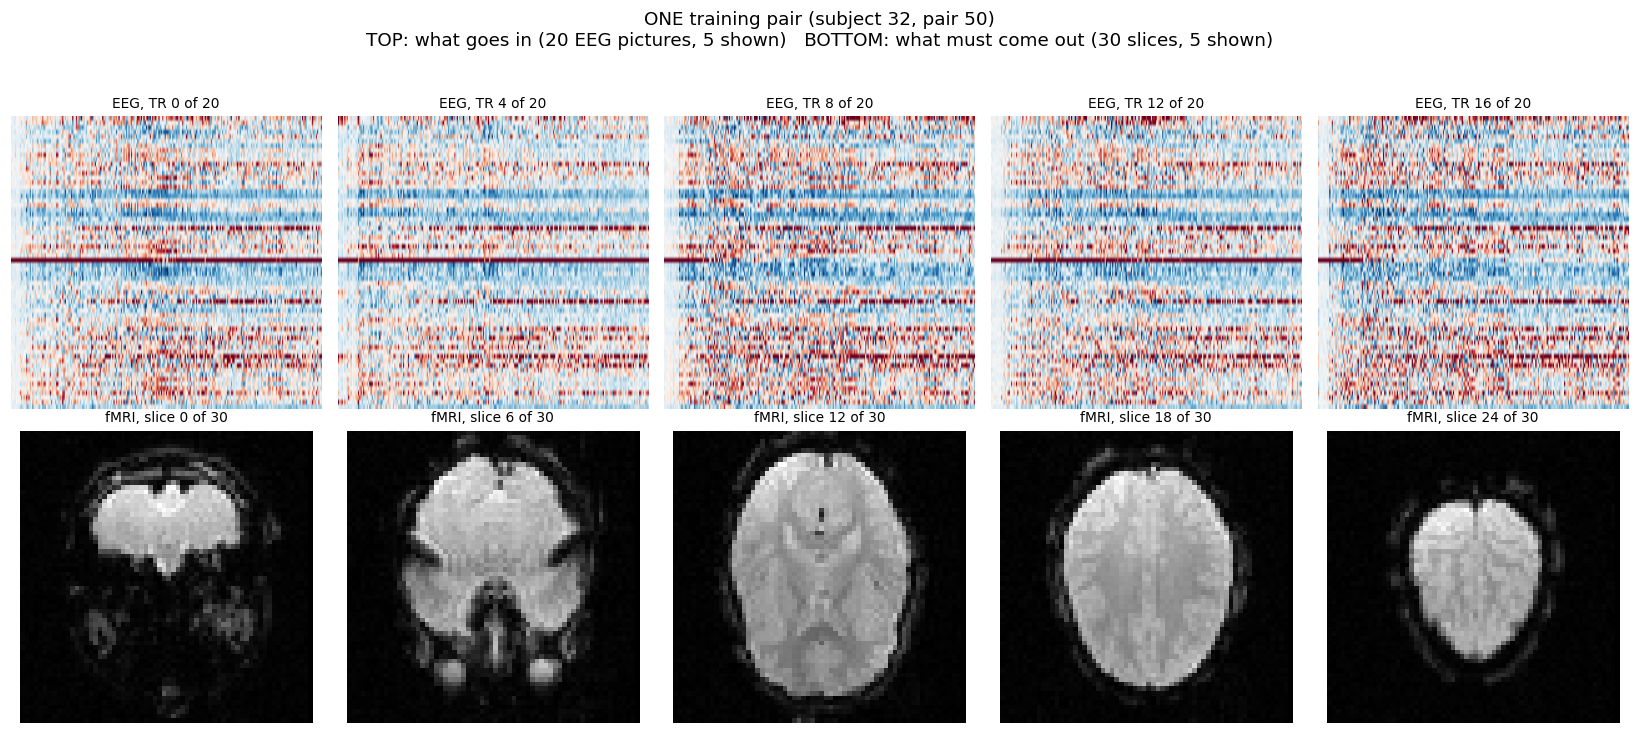

Top row    : 64 channels (vertical) x 249 frequencies (horizontal), per TR
             red = more power than the other channels at that frequency,
             blue = less. Remember z-scoring is ACROSS channels (Part 4).
Bottom row : the fMRI volume that follows those 20 windows

The model's entire job is to get from the top row to the bottom row.


In [15]:
pair = 50

fig = plt.figure(figsize=(15, 6.5))

# Top row: 5 of the 20 EEG history windows (every 4th one).
for j in range(5):
    ax = fig.add_subplot(2, 5, j + 1)
    step = j * 4
    # NOTE: no log scaling here. In Part 4 the spectrograms were raw (all positive)
    # so log helped. These are z-scored, so they go NEGATIVE - and log of a negative
    # number is undefined, which would fill the picture with NaNs.
    # A diverging colour map centred on 0 is the right choice for z-scores:
    # blue = below the channel average, red = above it.
    ax.imshow(eeg_final[pair, step], aspect="auto", cmap="RdBu_r",
              vmin=-2, vmax=2)
    ax.set_title(f"EEG, TR {step} of 20", fontsize=9)
    ax.axis("off")

# Bottom row: 5 of the 30 slices of the target volume (every 6th one).
for j in range(5):
    ax = fig.add_subplot(2, 5, j + 6)
    ax.imshow(np.rot90(fmri_final[pair, j * 6], k=-1), cmap="gray")
    ax.set_title(f"fMRI, slice {j*6} of 30", fontsize=9)
    ax.axis("off")

fig.suptitle(f"ONE training pair (subject {SUBJECT}, pair {pair})\n"
             f"TOP: what goes in (20 EEG pictures, 5 shown)   "
             f"BOTTOM: what must come out (30 slices, 5 shown)", y=1.02)
plt.tight_layout()
plt.show()

print("Top row    : 64 channels (vertical) x 249 frequencies (horizontal), per TR")
print("             red = more power than the other channels at that frequency,")
print("             blue = less. Remember z-scoring is ACROSS channels (Part 4).")
print("Bottom row : the fMRI volume that follows those 20 windows")
print()
print("The model's entire job is to get from the top row to the bottom row.")

## Step 10 - Disk space, before you run the real thing

This is the practical warning nobody mentions, and it will bite you if your `E:` drive is short.

The arrays are saved as **float64** - 8 bytes per number, with no compression.

In [16]:
eeg_mb  = eeg_final.nbytes  / 1024**2
fmri_mb = fmri_final.nbytes / 1024**2

print(f"Per subject:")
print(f"  eeg  : {eeg_mb:7.0f} MB   ({eeg_final.size:>12,} numbers x 8 bytes)")
print(f"  fmri : {fmri_mb:7.0f} MB   ({fmri_final.size:>12,} numbers x 8 bytes)")
print(f"  total: {eeg_mb + fmri_mb:7.0f} MB")
print()

n_subjects = len(usable)
total_gb = (eeg_mb + fmri_mb) * n_subjects / 1024
print(f"For all {n_subjects} subjects: about {total_gb:.1f} GB")
print()
print("Check you have that free BEFORE running process_data.py. It writes one")
print("file per subject as it goes, so running out of space part way leaves you")
print("with a partial dataset and a confusing error.")
print()
print("Note the EEG side is over twice the size of the fMRI side, which is not")
print("what you would guess from the shapes alone.")

Per subject:
  eeg  :     666 MB   (  87,329,280 numbers x 8 bytes)
  fmri :     257 MB   (  33,669,120 numbers x 8 bytes)
  total:     923 MB

For all 16 subjects: about 14.4 GB

Check you have that free BEFORE running process_data.py. It writes one
file per subject as it goes, so running out of space part way leaves you
with a partial dataset and a confusing error.

Note the EEG side is over twice the size of the fMRI side, which is not
what you would guess from the shapes alone.


### Could it be smaller?

Yes, easily. The data is float64 but nothing needs that precision - the EEG is z-scored and the
fMRI is scaled to 0-1, so `float32` would halve the size with no meaningful loss. HDF5 also
supports compression via `create_dataset(..., compression="gzip")`.

The repo does neither. If disk space is your constraint, changing `save_h5_data_NODDI` to write
float32 is a one-line edit and a legitimate thing to mention in your report as a practical
modification.

## Step 11 - Verify a real processed dataset

Once you have run:

```bash
python3 process_data.py --data_name NODDI
```

run this cell against the output. It is the check that tells you whether the pipeline did what you
think it did.

In [17]:
# Point this at processed_data_roots["NODDI"] from data_cfg.py.
H5_DIR = Path(r"E:\EEG_to_FMRI\NODDI_h5_data")   # <- edit me

expected_pairs_each = N_VOLUMES - INTERVAL_EEG    # 274
expected_eeg_shape  = (INTERVAL_EEG, 64, 249)     # per pair
expected_fmri_shape = (30, 64, 64)                # per pair

if not H5_DIR.is_dir():
    print(f"Not found: {H5_DIR}")
    print("Run process_data.py first, or fix the path above.")
else:
    files = sorted(H5_DIR.glob("*.h5"))
    total = 0
    problems = []

    print(f"{'file':<12}{'pairs':>7}  {'eeg shape':<24}{'fmri shape':<22}status")
    print("=" * 82)

    for fp in files:
        with h5py.File(fp, "r") as hf:
            e_shape = hf["eeg"].shape
            m_shape = hf["fmri"].shape

        total += e_shape[0]

        # Collect any problems for this file rather than stopping at the first.
        issues = []
        if e_shape[0] != expected_pairs_each:
            issues.append(f"{e_shape[0]} pairs, expected {expected_pairs_each}")
        if e_shape[1:] != expected_eeg_shape:
            issues.append(f"eeg shape {e_shape[1:]}")
        if m_shape[1:] != expected_fmri_shape:
            issues.append(f"fmri shape {m_shape[1:]}")
        if e_shape[0] != m_shape[0]:
            issues.append("eeg/fmri counts differ")

        status = "ok" if not issues else "; ".join(issues)
        if issues:
            problems.append(fp.name)

        print(f"{fp.name:<12}{e_shape[0]:>7}  {str(e_shape[1:]):<24}{str(m_shape[1:]):<22}{status}")

    print("=" * 82)
    print(f"{len(files)} files, {total:,} pairs total")
    print(f"Expected: {len(usable)} files, {len(usable)*expected_pairs_each:,} pairs")
    print()
    if problems:
        print(f"PROBLEMS in: {problems}")
    elif len(files) == len(usable) and total == len(usable) * expected_pairs_each:
        print("Everything checks out. Your dataset is ready to train on.")
    else:
        print("Counts do not match. Re-run Step 2 - a subject is probably missing")
        print("from one side or the other.")

Not found: E:\EEG_to_FMRI\NODDI_h5_data
Run process_data.py first, or fix the path above.


In [18]:
# One more check worth doing: are the values in a sane range?
# A silently broken pipeline often produces NaNs or all-zeros, and shape checks miss both.

if H5_DIR.is_dir() and list(H5_DIR.glob("*.h5")):
    fp = sorted(H5_DIR.glob("*.h5"))[0]
    with h5py.File(fp, "r") as hf:
        e = hf["eeg"][:20]      # just the first 20 pairs, to stay fast
        m = hf["fmri"][:20]

    print(f"Sampling the first 20 pairs of {fp.name}")
    print()
    # np.isnan finds "not a number" values; .any() asks whether there are any at all.
    print(f"  eeg  range {e.min():8.2f} to {e.max():8.2f}   NaNs: {np.isnan(e).any()}")
    print(f"  fmri range {m.min():8.2f} to {m.max():8.2f}   NaNs: {np.isnan(m).any()}")
    print()
    print("Expected: eeg roughly -4 to +10 (z-scored), fmri exactly 0.00 to 1.00,")
    print("and no NaNs anywhere. All-zeros or NaNs mean something went wrong upstream.")

## Step 12 - The gotchas, collected

Everything that can bite you between here and a trained model.

**1. `process_data.py` crashes if the output folder already exists.**

```python
os.makedirs(dest_dir)     # no exist_ok=True
```

Bare `os.makedirs` raises `FileExistsError` if the folder is there. Re-running after a partial
failure will fail immediately, for a reason that has nothing to do with the actual problem. Delete
or rename the output folder before every re-run.

**2. Your data folder must be writable.** `correct_vhdr_path` rewrites the `.vhdr` headers in
place (Part 3, Step 8). A read-only drive fails here.

**3. Folder names must match between `EEG/` and `fMRI/`.** A subject in fMRI but not EEG is
silently dropped. Step 2 above catches this.

**4. No `__MACOSX` or `.DS_Store` in `EEG/`.** `process_data.py` does
`os.listdir(data_dir/"EEG")` with no filtering, so junk folders become "subjects" and crash it.

**5. Check your free disk space** against Step 10 before starting.

**6. Subject 41 should not exist.** If it does, you downloaded version 1 of the dataset. Version 2
removed it as a duplicate.

---

### The layout `process_data.py` requires

```
<raw_data_roots["NODDI"]>/
├── EEG/
│   ├── 32/export/*.vhdr  (+ .vmrk, .dat)
│   ├── 35/export/...
│   └── ... 16 subject folders
└── fMRI/
    ├── 32/*_cross.nii.gz
    ├── 35/...
    └── ... 16 subject folders
```

Your archives do not unzip into this shape. In PowerShell:

```powershell
cd E:\EEG_to_FMRI
mkdir NODDI\EEG, NODDI\fMRI
Move-Item EEG1\EEG1\* NODDI\EEG\
Move-Item EEG2\EEG2\* NODDI\EEG\
Move-Item fMRI\fMRI\* NODDI\fMRI\
Remove-Item -Recurse -Force EEG1, EEG2, fMRI
Remove-Item NODDI\fMRI\.DS_Store -ErrorAction SilentlyContinue
```

Then in `data_cfg.py`:

```python
raw_data_roots       = {"NODDI": "E:/EEG_to_FMRI/NODDI/"}
processed_data_roots = {"NODDI": "E:/EEG_to_FMRI/NODDI_h5_data"}
```

## Step 13 - What you now know

| thing | value | why it matters |
|---|---|---|
| pairing rule | windows i..i+19 -> volume i+20 | the target is never inside the input |
| history length | 20 TRs = 43.2 s | long enough to contain the BOLD cause |
| pairs per subject | 294 - 20 = **274** | not 300, not 294 |
| total pairs | 16 x 274 = **4,384** | not 4,800 |
| eeg tensor | (274, 20, 64, 249) | pairs, history, channels, frequencies |
| fmri tensor | (274, 30, 64, 64) | pairs, slices, height, width |
| file size | ~900 MB per subject | about 14 GB for the full set |
| `np.empty` | uninitialised memory | a skipped row would train on garbage |
| `os.makedirs` | no `exist_ok` | delete the output folder before re-running |

---

### The whole pipeline, in one place

```
RAW                     300 volumes            EEG at 250 Hz
                             |                       |
bold_shift=6            drop first 6            drop first 6 windows
                             |                       |
                        294 volumes            294 spectrograms
                             |                       |
normalise               per-volume 0-1         z-score across channels
                             |                       |
                             +-----------+-----------+
                                         |
pair, interval=20          windows i..i+19  ->  volume i+20
                                         |
                                   274 pairs
                                         |
                                   subject.h5
```

---

### Try these

1. In Step 6, change `INTERVAL_EEG` to 10 and rebuild. How many pairs now? Does the formula hold?
2. In Step 9, change `pair` to 0 and then 273. The first and last examples in the dataset.
3. In Step 3, change `SUBJECT` to `usable[1]` and run the whole notebook. Does subject 2 produce 274 pairs too?
4. In Step 6, print `x_eeg[273]` and check it is not all zeros - that is the row most at risk from the `np.empty` issue.

---

### Where you are now

You have read every transformation between the raw scanner output and the tensors the network
trains on, and verified each one against your own data. That is the part most people skip, and it
is the part that makes the difference between a report that describes results and one that
explains them.

Next steps, in order:

1. Reorganise the folders (Step 12) and edit `data_cfg.py`
2. Run `python3 process_data.py --data_name NODDI`
3. Come back to Step 11 and verify the output
4. Only then start on training

For training, remember the Vision-Mamba decoder needs CUDA compilation and breaks often. If it
fights you, `train_E2fNet.py` in the same repo is plain convolutional PyTorch with no Mamba
dependency, and reaches SSIM around 0.605 on NODDI - more than enough for a course project, and
it uses these exact same `.h5` files.